**Libraries**

In [271]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# pd.set_option('display.max_rows', 7000)
import sklearn

In [272]:
df1 = pd.read_table('/home/surya/Desktop/recsys_nb/movies.dat', header=None, delimiter='::')
df2 = pd.read_table('/home/surya/Desktop/recsys_nb/ratings.dat', header=None, delimiter='::')
df3 = pd.read_table('/home/surya/Desktop/recsys_nb/users.dat', header=None, delimiter='::')

/tmp/ipykernel_58880/2008990726.py:1: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.
  df1 = pd.read_table('/home/surya/Desktop/recsys_nb/movies.dat', header=None, delimiter='::')
/tmp/ipykernel_58880/2008990726.py:2: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.
  df2 = pd.read_table('/home/surya/Desktop/recsys_nb/ratings.dat', header=None, delimiter='::')
/tmp/ipykernel_58880/2008990726.py:3: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specif

In [273]:
df1

,0,1,2
0,1,Toy Story (1995),Animation|Children's|Comedy
1,2,Jumanji (1995),Adventure|Children's|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama
4,5,Father of the Bride Part II (1995),Comedy
...,...,...,...
3878,3948,Meet the Parents (2000),Comedy
3879,3949,Requiem for a Dream (2000),Drama
3880,3950,Tigerland (2000),Drama
3881,3951,Two Family House (2000),Drama


In [274]:
df1.rename(columns = {0:'MovieID',
                         1:'Title',
                         2:'Genres'},
              inplace = True)

In [275]:
df2

,0,1,2,3
0,1,1193,5,978300760
1,1,661,3,978302109
2,1,914,3,978301968
3,1,3408,4,978300275
4,1,2355,5,978824291
...,...,...,...,...
1000204,6040,1091,1,956716541
1000205,6040,1094,5,956704887
1000206,6040,562,5,956704746
1000207,6040,1096,4,956715648


In [276]:
df2.rename(columns = {0:'UserID',
                         1:'MovieID',
                         2:'Rating',
                      3:'Timestamp'},
              inplace = True)

In [277]:
df1

,MovieID,Title,Genres
0,1,Toy Story (1995),Animation|Children's|Comedy
1,2,Jumanji (1995),Adventure|Children's|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama
4,5,Father of the Bride Part II (1995),Comedy
...,...,...,...
3878,3948,Meet the Parents (2000),Comedy
3879,3949,Requiem for a Dream (2000),Drama
3880,3950,Tigerland (2000),Drama
3881,3951,Two Family House (2000),Drama


In [278]:
df2

,UserID,MovieID,Rating,Timestamp
0,1,1193,5,978300760
1,1,661,3,978302109
2,1,914,3,978301968
3,1,3408,4,978300275
4,1,2355,5,978824291
...,...,...,...,...
1000204,6040,1091,1,956716541
1000205,6040,1094,5,956704887
1000206,6040,562,5,956704746
1000207,6040,1096,4,956715648


In [279]:
df3.rename(columns = {0:'UserID',
                         1:'Gender',
                         2:'Age',
                      3:'Occupation',
                      4:'Zip-code'},
              inplace = True)

In [280]:
df3

,UserID,Gender,Age,Occupation,Zip-code
0,1,F,1,10,48067
1,2,M,56,16,70072
2,3,M,25,15,55117
3,4,M,45,7,02460
4,5,M,25,20,55455
...,...,...,...,...,...
6035,6036,F,25,15,32603
6036,6037,F,45,1,76006
6037,6038,F,56,1,14706
6038,6039,F,45,0,01060


In [281]:
movie_ratings = df2.merge(df1, on='MovieID')
movie_ratings['Title'].value_counts()[0:10]

American Beauty (1999)                                   3428
Star Wars: Episode IV - A New Hope (1977)                2991
Star Wars: Episode V - The Empire Strikes Back (1980)    2990
Star Wars: Episode VI - Return of the Jedi (1983)        2883
Jurassic Park (1993)                                     2672
Saving Private Ryan (1998)                               2653
Terminator 2: Judgment Day (1991)                        2649
Matrix, The (1999)                                       2590
Back to the Future (1985)                                2583
Silence of the Lambs, The (1991)                         2578
Name: Title, dtype: int64

In [282]:
df = pd.merge(df1,df2,how="outer",on="MovieID")

In [283]:
df.head()

,MovieID,Title,Genres,UserID,Rating,Timestamp
0,1,Toy Story (1995),Animation|Children's|Comedy,1.0,5.0,978824268.0
1,1,Toy Story (1995),Animation|Children's|Comedy,6.0,4.0,978237008.0
2,1,Toy Story (1995),Animation|Children's|Comedy,8.0,4.0,978233496.0
3,1,Toy Story (1995),Animation|Children's|Comedy,9.0,5.0,978225952.0
4,1,Toy Story (1995),Animation|Children's|Comedy,10.0,5.0,978226474.0


In [284]:
df = pd.merge(df3,df,how="outer",on="UserID")

In [285]:
df4 = df
df

,UserID,Gender,Age,Occupation,Zip-code,MovieID,Title,Genres,Rating,Timestamp
0,1.0,F,1.0,10.0,48067,1,Toy Story (1995),Animation|Children's|Comedy,5.0,978824268.0
1,1.0,F,1.0,10.0,48067,48,Pocahontas (1995),Animation|Children's|Musical|Romance,5.0,978824351.0
2,1.0,F,1.0,10.0,48067,150,Apollo 13 (1995),Drama,5.0,978301777.0
3,1.0,F,1.0,10.0,48067,260,Star Wars: Episode IV - A New Hope (1977),Action|Adventure|Fantasy|Sci-Fi,4.0,978300760.0
4,1.0,F,1.0,10.0,48067,527,Schindler's List (1993),Drama|War,5.0,978824195.0
...,...,...,...,...,...,...,...,...,...,...
1000381,NaN,NaN,NaN,NaN,NaN,3650,Anguish (Angustia) (1986),Horror,NaN,NaN
1000382,NaN,NaN,NaN,NaN,NaN,3750,Boricua's Bond (2000),Drama,NaN,NaN
1000383,NaN,NaN,NaN,NaN,NaN,3829,Mad About Mambo (2000),Comedy|Romance,NaN,NaN
1000384,NaN,NaN,NaN,NaN,NaN,3856,Autumn Heart (1999),Drama,NaN,NaN


In [286]:
df.isna().sum()

UserID        177
Gender        177
Age           177
Occupation    177
Zip-code      177
MovieID         0
Title           0
Genres          0
Rating        177
Timestamp     177
dtype: int64

In [287]:
df.dropna(inplace=True)
df4.dropna(inplace=True)

In [288]:
df.isna().sum()

UserID        0
Gender        0
Age           0
Occupation    0
Zip-code      0
MovieID       0
Title         0
Genres        0
Rating        0
Timestamp     0
dtype: int64

In [289]:
df

,UserID,Gender,Age,Occupation,Zip-code,MovieID,Title,Genres,Rating,Timestamp
0,1.0,F,1.0,10.0,48067,1,Toy Story (1995),Animation|Children's|Comedy,5.0,978824268.0
1,1.0,F,1.0,10.0,48067,48,Pocahontas (1995),Animation|Children's|Musical|Romance,5.0,978824351.0
2,1.0,F,1.0,10.0,48067,150,Apollo 13 (1995),Drama,5.0,978301777.0
3,1.0,F,1.0,10.0,48067,260,Star Wars: Episode IV - A New Hope (1977),Action|Adventure|Fantasy|Sci-Fi,4.0,978300760.0
4,1.0,F,1.0,10.0,48067,527,Schindler's List (1993),Drama|War,5.0,978824195.0
...,...,...,...,...,...,...,...,...,...,...
1000204,6040.0,M,25.0,6.0,11106,3683,Blood Simple (1984),Drama|Film-Noir,4.0,960971696.0
1000205,6040.0,M,25.0,6.0,11106,3703,Mad Max 2 (a.k.a. The Road Warrior) (1981),Action|Sci-Fi,4.0,964828575.0
1000206,6040.0,M,25.0,6.0,11106,3735,Serpico (1973),Crime|Drama,4.0,960971654.0
1000207,6040.0,M,25.0,6.0,11106,3751,Chicken Run (2000),Animation|Children's|Comedy,4.0,964828782.0


In [290]:
df['Genres'] = df['Genres'].apply(lambda x: x.split('|'))

In [291]:
df

,UserID,Gender,Age,Occupation,Zip-code,MovieID,Title,Genres,Rating,Timestamp
0,1.0,F,1.0,10.0,48067,1,Toy Story (1995),"[Animation, Children's, Comedy]",5.0,978824268.0
1,1.0,F,1.0,10.0,48067,48,Pocahontas (1995),"[Animation, Children's, Musical, Romance]",5.0,978824351.0
2,1.0,F,1.0,10.0,48067,150,Apollo 13 (1995),[Drama],5.0,978301777.0
3,1.0,F,1.0,10.0,48067,260,Star Wars: Episode IV - A New Hope (1977),"[Action, Adventure, Fantasy, Sci-Fi]",4.0,978300760.0
4,1.0,F,1.0,10.0,48067,527,Schindler's List (1993),"[Drama, War]",5.0,978824195.0
...,...,...,...,...,...,...,...,...,...,...
1000204,6040.0,M,25.0,6.0,11106,3683,Blood Simple (1984),"[Drama, Film-Noir]",4.0,960971696.0
1000205,6040.0,M,25.0,6.0,11106,3703,Mad Max 2 (a.k.a. The Road Warrior) (1981),"[Action, Sci-Fi]",4.0,964828575.0
1000206,6040.0,M,25.0,6.0,11106,3735,Serpico (1973),"[Crime, Drama]",4.0,960971654.0
1000207,6040.0,M,25.0,6.0,11106,3751,Chicken Run (2000),"[Animation, Children's, Comedy]",4.0,964828782.0


In [292]:
all_genres = set(genre for sublist in df['Genres'] for genre in sublist)

In [293]:
for genre in all_genres:
    df[f'{genre}'] = df['Genres'].apply(lambda x: 1 if genre in x else 0)
df = df.drop(columns=['Genres'])

In [294]:
df

,UserID,Gender,Age,Occupation,Zip-code,MovieID,Title,Rating,Timestamp,Adventure,...,Western,Film-Noir,Mystery,Thriller,Horror,Romance,Drama,Musical,War,Fantasy
0,1.0,F,1.0,10.0,48067,1,Toy Story (1995),5.0,978824268.0,0,...,0,0,0,0,0,0,0,0,0,0
1,1.0,F,1.0,10.0,48067,48,Pocahontas (1995),5.0,978824351.0,0,...,0,0,0,0,0,1,0,1,0,0
2,1.0,F,1.0,10.0,48067,150,Apollo 13 (1995),5.0,978301777.0,0,...,0,0,0,0,0,0,1,0,0,0
3,1.0,F,1.0,10.0,48067,260,Star Wars: Episode IV - A New Hope (1977),4.0,978300760.0,1,...,0,0,0,0,0,0,0,0,0,1
4,1.0,F,1.0,10.0,48067,527,Schindler's List (1993),5.0,978824195.0,0,...,0,0,0,0,0,0,1,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1000204,6040.0,M,25.0,6.0,11106,3683,Blood Simple (1984),4.0,960971696.0,0,...,0,1,0,0,0,0,1,0,0,0
1000205,6040.0,M,25.0,6.0,11106,3703,Mad Max 2 (a.k.a. The Road Warrior) (1981),4.0,964828575.0,0,...,0,0,0,0,0,0,0,0,0,0
1000206,6040.0,M,25.0,6.0,11106,3735,Serpico (1973),4.0,960971654.0,0,...,0,0,0,0,0,0,1,0,0,0
1000207,6040.0,M,25.0,6.0,11106,3751,Chicken Run (2000),4.0,964828782.0,0,...,0,0,0,0,0,0,0,0,0,0


EDA

In [295]:
ratings_cnt = len(df['Rating'])
movies_cnt = df['MovieID'].nunique()
users_cnt = df['UserID'].nunique()

In [296]:
ratings_cnt

1000209

In [297]:
print(movies_cnt)
print(users_cnt)

3706
6040


/tmp/ipykernel_58880/544676893.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Rating',data=df,palette="viridis")


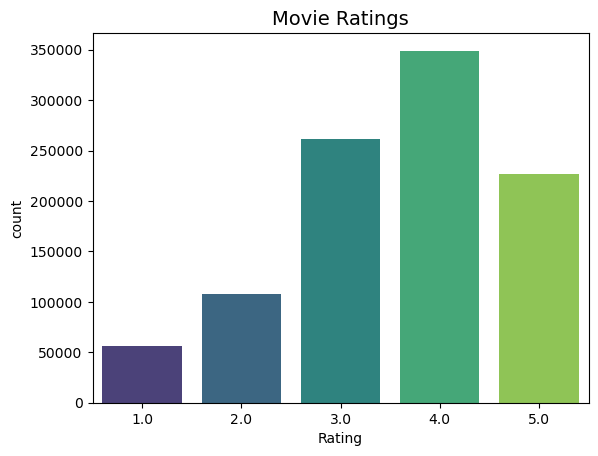

In [298]:
sns.countplot(x='Rating',data=df,palette="viridis")
plt.title('Movie Ratings', fontsize = 14)
plt.show()

Non uniform distribution

In [299]:
print(f"Mean rating: {round(df['Rating'].mean(),2)}.")

Mean rating: 3.58.


In [300]:
mean_ratings = df.groupby('UserID')['Rating'].mean()
print(f"Mean rating per user: {round(mean_ratings.mean(),2)}.")

Mean rating per user: 3.7.


In [301]:
movie_ratings = df2.merge(df1, on='MovieID')
movie_ratings['Title'].value_counts()[0:10]

American Beauty (1999)                                   3428
Star Wars: Episode IV - A New Hope (1977)                2991
Star Wars: Episode V - The Empire Strikes Back (1980)    2990
Star Wars: Episode VI - Return of the Jedi (1983)        2883
Jurassic Park (1993)                                     2672
Saving Private Ryan (1998)                               2653
Terminator 2: Judgment Day (1991)                        2649
Matrix, The (1999)                                       2590
Back to the Future (1985)                                2583
Silence of the Lambs, The (1991)                         2578
Name: Title, dtype: int64

Recommendation

In [302]:
df.head()

,UserID,Gender,Age,Occupation,Zip-code,MovieID,Title,Rating,Timestamp,Adventure,...,Western,Film-Noir,Mystery,Thriller,Horror,Romance,Drama,Musical,War,Fantasy
0,1.0,F,1.0,10.0,48067,1,Toy Story (1995),5.0,978824268.0,0,...,0,0,0,0,0,0,0,0,0,0
1,1.0,F,1.0,10.0,48067,48,Pocahontas (1995),5.0,978824351.0,0,...,0,0,0,0,0,1,0,1,0,0
2,1.0,F,1.0,10.0,48067,150,Apollo 13 (1995),5.0,978301777.0,0,...,0,0,0,0,0,0,1,0,0,0
3,1.0,F,1.0,10.0,48067,260,Star Wars: Episode IV - A New Hope (1977),4.0,978300760.0,1,...,0,0,0,0,0,0,0,0,0,1
4,1.0,F,1.0,10.0,48067,527,Schindler's List (1993),5.0,978824195.0,0,...,0,0,0,0,0,0,1,0,1,0


In [303]:
df.columns

Index(['UserID', 'Gender', 'Age', 'Occupation', 'Zip-code', 'MovieID', 'Title',
       'Rating', 'Timestamp', 'Adventure', 'Documentary', 'Sci-Fi',
       'Children's', 'Action', 'Crime', 'Animation', 'Comedy', 'Western',
       'Film-Noir', 'Mystery', 'Thriller', 'Horror', 'Romance', 'Drama',
       'Musical', 'War', 'Fantasy'],
      dtype='object')

In [304]:
df['Gender'] = df['Gender'].replace({'M': 1, 'F': 0})

In [305]:
df.head()

,UserID,Gender,Age,Occupation,Zip-code,MovieID,Title,Rating,Timestamp,Adventure,...,Western,Film-Noir,Mystery,Thriller,Horror,Romance,Drama,Musical,War,Fantasy
0,1.0,0,1.0,10.0,48067,1,Toy Story (1995),5.0,978824268.0,0,...,0,0,0,0,0,0,0,0,0,0
1,1.0,0,1.0,10.0,48067,48,Pocahontas (1995),5.0,978824351.0,0,...,0,0,0,0,0,1,0,1,0,0
2,1.0,0,1.0,10.0,48067,150,Apollo 13 (1995),5.0,978301777.0,0,...,0,0,0,0,0,0,1,0,0,0
3,1.0,0,1.0,10.0,48067,260,Star Wars: Episode IV - A New Hope (1977),4.0,978300760.0,1,...,0,0,0,0,0,0,0,0,0,1
4,1.0,0,1.0,10.0,48067,527,Schindler's List (1993),5.0,978824195.0,0,...,0,0,0,0,0,0,1,0,1,0


mapping with user id and genre

In [306]:
k_means_df = df.drop(columns=['Timestamp', 'Zip-code'])

In [307]:
k_means_df.columns

Index(['UserID', 'Gender', 'Age', 'Occupation', 'MovieID', 'Title', 'Rating',
       'Adventure', 'Documentary', 'Sci-Fi', 'Children's', 'Action', 'Crime',
       'Animation', 'Comedy', 'Western', 'Film-Noir', 'Mystery', 'Thriller',
       'Horror', 'Romance', 'Drama', 'Musical', 'War', 'Fantasy'],
      dtype='object')

In [308]:
k_means_df = k_means_df.drop(['Gender', 'Age', 'Occupation', 'MovieID', 'Title'],axis=1)

In [309]:
k_means_df.head()

,UserID,Rating,Adventure,Documentary,Sci-Fi,Children's,Action,Crime,Animation,Comedy,Western,Film-Noir,Mystery,Thriller,Horror,Romance,Drama,Musical,War,Fantasy
0,1.0,5.0,0,0,0,1,0,0,1,1,0,0,0,0,0,0,0,0,0,0
1,1.0,5.0,0,0,0,1,0,0,1,0,0,0,0,0,0,1,0,1,0,0
2,1.0,5.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0
3,1.0,4.0,1,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1
4,1.0,5.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0


In [310]:
genre_list = ['Action','Adventure',
	'Animation',
	"Children's",
	'Comedy',
	 'Crime',
	'Documentary',
	 'Drama',
	 'Fantasy',
	 'Film-Noir',
	 'Horror',
	 'Musical',
	 'Mystery','Romance','Sci-Fi','Thriller','War','Western']

for genre in genre_list:
    k_means_df[genre] *= k_means_df['Rating']

In [311]:
grouped_data = k_means_df.groupby('UserID').mean()
len(grouped_data.columns)

19

In [312]:
grouped_data.describe()
grouped_data_df = grouped_data

In [313]:
grouped_data = np.array(grouped_data)


In [314]:
grouped_data.shape

(6040, 19)

In [315]:
grouped_data

array([[4.18867925, 0.37735849, 0.        , ..., 1.13207547, 0.18867925,
        0.22641509],
       [3.71317829, 0.5503876 , 0.        , ..., 0.        , 0.43410853,
        0.02325581],
       [3.90196078, 1.96078431, 0.        , ..., 0.07843137, 0.15686275,
        0.17647059],
       ...,
       [3.8       , 0.2       , 0.        , ..., 0.        , 0.8       ,
        0.        ],
       [3.87804878, 0.33333333, 0.        , ..., 1.2601626 , 0.30081301,
        0.14634146],
       [3.57771261, 0.18181818, 0.13196481, ..., 0.10557185, 0.24926686,
        0.06158358]])

In [316]:
from SVD import *
from Kmeans import *

SVD(grouped_data)

In [317]:
u,s,sigma,V_trans = ReducedSVD(grouped_data, 0, 2)

In [318]:
mat = u@sigma@V_trans

In [319]:
# iter = 100
# kmeans = Kmeans(9, iter, 2, 'Euclidean')
# cluster_label, centroids = kmeans.predict(mat)

In [320]:
# cluster_label

In [321]:
def cluster_to_matrix(X_train,y_train,num_cluster):
    k = Kmeans(K=num_cluster, iter=150, p=2, random_state=42)
    y_pred,_=k.predict(np.array(X_train),choice=0)
    k.centroids=np.array(k.centroids)
    empty_cluster = []
    for idx,i in enumerate(k.clusters):
        if len(i)==0:
            empty_cluster.append(idx)
    X_train2 = pd.concat([X_train,y_train,pd.DataFrame(y_pred,columns=["label"],dtype='int')],axis="columns")
    df_cluster_rep = X_train2.groupby(['label'], as_index=False).mean()
    df_cluster_rep.drop(labels="label",axis="columns",inplace=True)
    matrix = df_cluster_rep.to_numpy()
    final_matrix = []
    j = 0 
    for i in range(num_cluster):
        if i in empty_cluster:
            final_matrix.append(np.zeros(len(df.columns)))
        else:
            final_matrix.append(matrix[j])
            j+=1

    return np.array(final_matrix),k

In [322]:
x_col_size = 4
y = grouped_data_df[grouped_data_df.columns[x_col_size:]]
x = grouped_data_df.drop(labels=grouped_data_df.columns[x_col_size:],axis="columns")

In [323]:
y

,Children's,Action,Crime,Animation,Comedy,Western,Film-Noir,Mystery,Thriller,Horror,Romance,Drama,Musical,War,Fantasy
UserID,,,,,,,,,,,,,,,
1.0,1.603774,0.396226,0.150943,1.396226,1.094340,0.000000,0.000000,0.000000,0.207547,0.000000,0.415094,1.754717,1.132075,0.188679,0.226415
2.0,0.000000,1.519380,0.333333,0.000000,0.689922,0.100775,0.031008,0.077519,0.837209,0.046512,0.689922,2.387597,0.000000,0.434109,0.023256
3.0,0.235294,1.784314,0.000000,0.235294,2.215686,0.549020,0.000000,0.058824,0.372549,0.156863,0.372549,0.627451,0.078431,0.156863,0.176471
4.0,0.190476,3.761905,0.238095,0.000000,0.000000,0.428571,0.000000,0.000000,0.666667,0.619048,0.380952,1.190476,0.000000,0.476190,0.428571
5.0,0.116162,0.409091,0.348485,0.080808,0.964646,0.020202,0.060606,0.126263,0.560606,0.141414,0.469697,1.626263,0.050505,0.106061,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6036.0,0.209459,0.520270,0.210586,0.149775,0.941441,0.057432,0.077703,0.130631,0.520270,0.248874,0.460586,1.468468,0.129505,0.179054,0.064189
6037.0,0.108911,0.504950,0.341584,0.019802,1.044554,0.074257,0.153465,0.237624,1.247525,0.183168,0.400990,1.881188,0.079208,0.316832,0.084158
6038.0,0.150000,0.300000,0.000000,0.550000,2.300000,0.000000,0.000000,0.000000,0.000000,0.250000,1.250000,1.750000,0.000000,0.800000,0.000000


In [324]:
x

,Rating,Adventure,Documentary,Sci-Fi
UserID,,,,
1.0,4.188679,0.377358,0.000000,0.245283
2.0,3.713178,0.550388,0.000000,0.472868
3.0,3.901961,1.960784,0.000000,0.450980
4.0,4.190476,1.095238,0.000000,1.523810
5.0,3.146465,0.136364,0.111111,0.232323
...,...,...,...,...
6036.0,3.302928,0.279279,0.048423,0.539414
6037.0,3.717822,0.178218,0.019802,0.712871
6038.0,3.800000,0.200000,0.000000,0.200000


In [325]:
from sklearn.model_selection import train_test_split
random_state = 42
X_train,X_test,y_train,y_test=train_test_split(x,y,test_size=0.1, shuffle=True,random_state=random_state)

In [326]:
X_train.shape

(5436, 4)

In [327]:
y_train.shape

(5436, 15)

In [328]:
y_train

,Children's,Action,Crime,Animation,Comedy,Western,Film-Noir,Mystery,Thriller,Horror,Romance,Drama,Musical,War,Fantasy
UserID,,,,,,,,,,,,,,,
2407.0,0.559211,0.289474,0.421053,0.328947,1.796053,0.105263,0.355263,0.342105,1.092105,0.184211,0.598684,1.467105,0.407895,0.315789,0.065789
747.0,0.000000,2.250000,0.125000,0.000000,1.062500,0.000000,0.000000,0.000000,0.968750,0.250000,0.125000,0.968750,0.000000,0.500000,0.250000
5427.0,0.160494,0.814815,0.481481,0.111111,1.901235,0.111111,0.296296,0.234568,0.679012,0.111111,0.370370,2.333333,0.123457,0.753086,0.061728
2674.0,0.042017,0.184874,0.546218,0.000000,1.924370,0.000000,0.302521,0.134454,0.462185,0.000000,0.546218,2.058824,0.067227,0.159664,0.000000
1091.0,0.242424,1.939394,0.000000,0.121212,0.515152,0.000000,0.000000,0.151515,1.454545,0.000000,0.575758,0.606061,0.030303,0.121212,0.090909
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3773.0,0.265928,0.620499,0.285319,0.119114,2.110803,0.074792,0.022161,0.047091,0.409972,0.221607,0.371191,0.900277,0.108033,0.141274,0.163435
5192.0,0.681818,1.136364,0.000000,0.409091,1.590909,0.181818,0.227273,0.454545,0.227273,0.000000,0.636364,1.272727,0.000000,0.227273,0.136364
5227.0,0.140127,2.630573,0.363057,0.000000,0.477707,0.038217,0.000000,0.057325,1.458599,0.197452,0.184713,0.382166,0.000000,0.184713,0.108280


In [329]:
matrix,kmeans_model = cluster_to_matrix(X_train,y_train,5)

In [330]:
matrix.shape

(5, 19)

In [331]:
def predict(datapoint,kmeans,matrix_clean):
    y_pred = kmeans.predictPoint(datapoint)
    inferred_full = matrix_clean[y_pred]
    inferred = inferred_full[x_col_size:]
    sorted_ratings = []
    for idx,element in enumerate(inferred):
        sorted_ratings.append([element,idx])
    sorted_ratings.sort()
    sorted_ratings.reverse()
    return sorted_ratings

In [332]:
# X_test.to_numpy()[0][:x_col_size]
sorted_ratings = predict(X_test.to_numpy()[0],kmeans_model,matrix)
s="Top 5 recommended genres are:\n"
for i in range(5):
    s+=y_train.columns[sorted_ratings[i][1]]+"\n"
print(s)

Top 5 recommended genres are:
Drama
Comedy
Action
Thriller
Romance



In [333]:
sorted_ratings_actual=[]
inferred = y_test.to_numpy()[0]
for idx,element in enumerate(inferred):
    sorted_ratings_actual.append([element,idx])
sorted_ratings_actual.sort()
sorted_ratings_actual.reverse()
s="Top 5 recommended genres are:\n"
for i in range(5):
    s+=y_test.columns[sorted_ratings_actual[i][1]]+"\n"
print(s)

Top 5 recommended genres are:
Drama
Comedy
Romance
Action
Children's



In [334]:
df4_exploded


,UserID,Gender,Age,Occupation,Zip-code,MovieID,Title,Genres,Rating,Timestamp,...,Western,Film-Noir,Mystery,Thriller,Horror,Romance,Drama,Musical,War,Fantasy
0,1.0,F,1.0,10.0,48067,1,Toy Story (1995),Animation,5.0,978824268.0,...,0,0,0,0,0,0,0,0,0,0
0,1.0,F,1.0,10.0,48067,1,Toy Story (1995),Children's,5.0,978824268.0,...,0,0,0,0,0,0,0,0,0,0
0,1.0,F,1.0,10.0,48067,1,Toy Story (1995),Comedy,5.0,978824268.0,...,0,0,0,0,0,0,0,0,0,0
1,1.0,F,1.0,10.0,48067,48,Pocahontas (1995),Animation,5.0,978824351.0,...,0,0,0,0,0,1,0,1,0,0
1,1.0,F,1.0,10.0,48067,48,Pocahontas (1995),Children's,5.0,978824351.0,...,0,0,0,0,0,1,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1000206,6040.0,M,25.0,6.0,11106,3735,Serpico (1973),Drama,4.0,960971654.0,...,0,0,0,0,0,0,1,0,0,0
1000207,6040.0,M,25.0,6.0,11106,3751,Chicken Run (2000),Animation,4.0,964828782.0,...,0,0,0,0,0,0,0,0,0,0
1000207,6040.0,M,25.0,6.0,11106,3751,Chicken Run (2000),Children's,4.0,964828782.0,...,0,0,0,0,0,0,0,0,0,0
1000207,6040.0,M,25.0,6.0,11106,3751,Chicken Run (2000),Comedy,4.0,964828782.0,...,0,0,0,0,0,0,0,0,0,0


In [335]:
df4_exploded = df4.explode('Genres')

# Get the index of the top-rated movie within each genre group
top_movies_indices = df4_exploded.groupby('Genres')['Rating'].idxmax()

# Extract the corresponding 'Title' column from the original DataFrame based on the indices
top_movies_titles = df4_exploded.loc[top_movies_indices, 'Title'].reset_index(drop=True)

# Print the titles of the top-rated movie from each genre
print(top_movies_titles)

0                                Ben-Hur (1959)
1                                Ben-Hur (1959)
2                                Ben-Hur (1959)
3                                Ben-Hur (1959)
4                                Ben-Hur (1959)
5                                Ben-Hur (1959)
6                              Toy Story (1995)
7                              Toy Story (1995)
8                              Toy Story (1995)
9                              Toy Story (1995)
10                             Toy Story (1995)
11                             Toy Story (1995)
12                             Toy Story (1995)
13                             Toy Story (1995)
14                             Toy Story (1995)
15                     On the Waterfront (1954)
16                     On the Waterfront (1954)
17                      Paris Is Burning (1990)
18                             Apollo 13 (1995)
19    Star Wars: Episode IV - A New Hope (1977)
20    Star Wars: Episode IV - A New Hope